# Implementation de l'active learning

In [13]:
import pandas as pd
import numpy as np
from joblib import load
from preprocessor import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from joblib import load
from modAL.models import ActiveLearner
from modAL.uncertainty import classifier_uncertainty


## Masquage des labels

In [14]:
# Chargement des donnees
data = pd.read_csv('/home/onyxia/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')
data.head(2)

,Unnamed: 0,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehiclePrice,FraudFound_P,...,Days_Policy_Accident,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,delay_weeks
0,0,Honda,Urban,Female,Single,21,Policy Holder,Sport - Liability,more than 69000,0,...,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1
1,1,Honda,Urban,Male,Single,34,Policy Holder,Sport - Collision,more than 69000,0,...,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,61


In [15]:
#Données non labelisees et des labels
X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']
X.head(3)

,Unnamed: 0,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehiclePrice,Deductible,...,Days_Policy_Accident,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,delay_weeks
0,0,Honda,Urban,Female,Single,21,Policy Holder,Sport - Liability,more than 69000,300,...,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1
1,1,Honda,Urban,Male,Single,34,Policy Holder,Sport - Collision,more than 69000,400,...,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,61
2,2,Honda,Urban,Male,Married,47,Policy Holder,Sport - Collision,more than 69000,400,...,more than 30,1,7 years,No,No,External,none,no change,1 vehicle,2


In [16]:
# Chargement du pipeline
preprocessor = load("preprocessor.joblib")

In [17]:
all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols # definit dans preprocessor.py
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)
X_preprocessed.head(2)

,AccidentArea,Sex,Fault,PoliceReportFiled,WitnessPresent,AgentType,Make,MaritalStatus,PolicyType,VehiclePrice,Days_Policy_Accident,PastNumberOfClaims,AgeOfVehicle,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,DriverRating,Deductible,Age,delay_weeks
0,1.0,0.0,1.0,0.0,0.0,0.0,6.0,2.0,0.000065,5.0,4.0,0.0,2.0,0.0,2.0,2.0,1.0,300.0,-1.516574,-1.856357
1,1.0,1.0,1.0,1.0,0.0,0.0,6.0,2.0,0.022570,5.0,4.0,0.0,5.0,0.0,0.0,0.0,4.0,400.0,-0.489689,0.602140


In [18]:
len(X_preprocessed)

15419

## Séparation des donnees en 3 parties test/seed/pool

In [19]:
# 20% pour le test
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42
)

# 2% d'observations initiales pour le seed dans le x_pool
X_init, X_pool, y_init, y_pool = train_test_split(
    X_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

In [20]:
# Donnees pour la methode par uncertainty sampling US (on prends les memes) 

X_init_US = X_init
X_pool_US = X_pool
y_init_US = y_init
y_pool_US = y_pool

In [21]:
print ("Nombre de lignes du pool final : ",len(X_pool) ,
 "; Nombre de lignes du seed : ", len(X_init))


Nombre de lignes du pool final :  12089 ; Nombre de lignes du seed :  246


## Initialisation du modèle et SMOTE

In [22]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    num_leaves= 47,
    max_depth= 11,
    learning_rate= 0.057,
    n_estimators= 780,
    subsample= 0.85,
    colsample_bytree= 0.72,
    reg_alpha= 0.012,
    reg_lambda= 0.045,
    min_child_samples= 23,
    scale_pos_weight= 8.5
)
smote = SMOTE(sampling_strategy=0.25, random_state=42)


In [23]:
model_US = LGBMClassifier(
   num_leaves= 47,
    max_depth= 11,
    learning_rate= 0.057,
    n_estimators= 780,
    subsample= 0.85,
    colsample_bytree= 0.72,
    reg_alpha= 0.012,
    reg_lambda= 0.045,
    min_child_samples= 23,
    scale_pos_weight= 8.5
)

## Boucle de l'active learning

In [24]:
# ── Fonctions de query custom ──────────────────────────────────────────────

def random_query(classifier, X_pool, n_instances=50, **kwargs):
    """Tirage aléatoire stratifié simulé via np.random."""
    n = min(n_instances, len(X_pool))
    idx = np.random.choice(len(X_pool), size=n, replace=False)
    return idx, X_pool[idx]


def youden_uncertainty_query(classifier, X_pool, n_instances=50,
                              X_init_ref=None, y_init_ref=None, **kwargs):
    """
    Sélectionne les n_instances observations du pool les plus proches
    du seuil de Youden calculé sur le seed courant.
    """
    # Calcul du seuil de Youden sur le init courant
    y_init_proba = classifier.predict_proba(X_init_ref)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_init_ref, y_init_proba)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    youden_threshold = thresholds[best_idx]

    # Distance au seuil
    y_pool_proba = classifier.predict_proba(X_pool)[:, 1]
    dist_to_threshold = np.abs(y_pool_proba - youden_threshold)

    n = min(n_instances, len(X_pool))
    idx = np.argsort(dist_to_threshold)[:n]
    return idx, X_pool[idx]


# ── Wrapper SMOTE + fit pour modAL ──────────────────────────────────────────

def smote_fit(estimator, X, y, smote_obj):
    """Applique SMOTE puis entraîne l'estimateur."""
    X_res, y_res = smote_obj.fit_resample(X, y)
    estimator.fit(X_res, y_res)


# ── Initialisation des ActiveLearners ───────────────────────────────────────

# Les ActiveLearner attendent des arrays numpy
X_init_arr    = X_init.values
y_init_arr    = y_init.values
X_pool_arr    = X_pool.values
y_pool_arr    = y_pool.values
X_test_arr    = X_test.values
y_test_arr    = y_test.values
X_init_US_arr = X_init_US.values
y_init_US_arr = y_init_US.values
X_pool_US_arr = X_pool_US.values
y_pool_US_arr = y_pool_US.values

# SMOTE initial avant de créer les learners
X_init_smote0,    y_init_smote0    = smote.fit_resample(X_init_arr,    y_init_arr)
X_init_US_smote0, y_init_US_smote0 = smote.fit_resample(X_init_US_arr, y_init_US_arr)

learner_RS = ActiveLearner(
    estimator=model,
    query_strategy=random_query,
    X_training=X_init_smote0,
    y_training=y_init_smote0
)

learner_US = ActiveLearner(
    estimator=model_US,
    query_strategy=youden_uncertainty_query,
    X_training=X_init_US_smote0,
    y_training=y_init_US_smote0
)

# Conserver les pools "vivants" séparément (modAL les modifie en interne
# uniquement si on utilise teach(), on gère le pool manuellement ici)
pool_RS    = X_pool_arr.copy()
y_pool_RS  = y_pool_arr.copy()
pool_US    = X_pool_US_arr.copy()
y_pool_US2 = y_pool_US_arr.copy()

# Garder trace du seed courant (pour Youden) sans SMOTE
X_seed_US = X_init_US_arr.copy()
y_seed_US = y_init_US_arr.copy()

# Taille du seed brut (sans SMOTE) pour la condition d'arrêt
n_init_RS = len(X_init_arr)
n_init_US = len(X_init_US_arr)

results = []

# ── Boucle Active Learning ───────────────────────────────────────────────────

while n_init_RS < 12089 and len(pool_RS) > 0:

    # ---- Évaluation sur le test set ----
    y_test_pred   = learner_RS.predict(X_test_arr)
    y_test_proba  = learner_RS.predict_proba(X_test_arr)[:, 1]

    y_test_US_pred  = learner_US.predict(X_test_arr)
    y_test_US_proba = learner_US.predict_proba(X_test_arr)[:, 1]

    results.append({
        "labels_used": n_init_RS,
        "accuracy_random_sampling":     accuracy_score(y_test_arr, y_test_pred),
        "f1_random_sampling":           f1_score(y_test_arr, y_test_pred),
        "recall_random_sampling":       recall_score(y_test_arr, y_test_pred),
        "precision_random_sampling":    precision_score(y_test_arr, y_test_pred),
        "auc_random_sampling":          roc_auc_score(y_test_arr, y_test_proba),
        "accuracy_uncertainty_sampling":  accuracy_score(y_test_arr, y_test_US_pred),
        "f1_uncertainty_sampling":        f1_score(y_test_arr, y_test_US_pred),
        "recall_uncertainty_sampling":    recall_score(y_test_arr, y_test_US_pred),
        "precision_uncertainty_sampling": precision_score(y_test_arr, y_test_US_pred),
        "auc_uncertainty_sampling":       roc_auc_score(y_test_arr, y_test_US_proba)
    })

    # =========================================================================
    # ---- Random Sampling via modAL ----
    # =========================================================================
    n_select_RS = min(50, len(pool_RS))
    query_idx_RS, _ = learner_RS.query(pool_RS, n_instances=n_select_RS)

    X_new_RS = pool_RS[query_idx_RS]
    y_new_RS = y_pool_RS[query_idx_RS]

    # Reconstruction du seed brut (sans SMOTE) pour SMOTE du prochain tour
    X_seed_RS_new = np.concatenate([
        X_seed_RS_new if 'X_seed_RS_new' in locals() else X_init_arr,
        X_new_RS
    ])
    y_seed_RS_new = np.concatenate([
        y_seed_RS_new if 'y_seed_RS_new' in locals() else y_init_arr,
        y_new_RS
    ])

    # SMOTE puis teach
    X_rs_smote, y_rs_smote = smote.fit_resample(X_seed_RS_new, y_seed_RS_new)
    learner_RS.estimator.fit(X_rs_smote, y_rs_smote)  # réentraîne sur seed complet smotté

    # Retrait du pool RS
    pool_RS   = np.delete(pool_RS,   query_idx_RS, axis=0)
    y_pool_RS = np.delete(y_pool_RS, query_idx_RS)
    n_init_RS += n_select_RS

    # =========================================================================
    # ---- Uncertainty Sampling (Youden) via modAL ----
    # =========================================================================
    n_select_US = min(50, len(pool_US))
    query_idx_US, _ = learner_US.query(
        pool_US,
        n_instances=n_select_US,
        X_init_ref=X_seed_US,
        y_init_ref=y_seed_US
    )

    X_new_US = pool_US[query_idx_US]
    y_new_US = y_pool_US2[query_idx_US]

    # Mise à jour du seed US brut
    X_seed_US = np.concatenate([X_seed_US, X_new_US])
    y_seed_US = np.concatenate([y_seed_US, y_new_US])

    # SMOTE puis réentraînement
    X_us_smote, y_us_smote = smote.fit_resample(X_seed_US, y_seed_US)
    learner_US.estimator.fit(X_us_smote, y_us_smote)

    # Retrait du pool US
    pool_US    = np.delete(pool_US,    query_idx_US, axis=0)
    y_pool_US2 = np.delete(y_pool_US2, query_idx_US)


# ── Résultats finaux ─────────────────────────────────────────────────────────

results_df = pd.DataFrame(results)
results_df


[LightGBM] [Info] Number of positive: 57, number of negative: 231
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197917 -> initscore=-1.399366
[LightGBM] [Info] Start training from score -1.399366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,labels_used,accuracy_random_sampling,f1_random_sampling,recall_random_sampling,precision_random_sampling,auc_random_sampling,accuracy_uncertainty_sampling,f1_uncertainty_sampling,recall_uncertainty_sampling,precision_uncertainty_sampling,auc_uncertainty_sampling
0,246,0.913424,0.135922,0.113514,0.169355,0.655641,0.913424,0.135922,0.113514,0.169355,0.655641
1,296,0.913100,0.135484,0.113514,0.168000,0.783101,0.926719,0.034188,0.021622,0.081633,0.555215
2,346,0.910830,0.137931,0.118919,0.164179,0.785568,0.934825,0.028986,0.016216,0.136364,0.618795
3,396,0.909533,0.141538,0.124324,0.164286,0.784856,0.934501,0.047170,0.027027,0.185185,0.629097
4,446,0.913748,0.152866,0.129730,0.186047,0.782840,0.937743,0.020408,0.010811,0.181818,0.659663
...,...,...,...,...,...,...,...,...,...,...,...
232,11846,0.904994,0.205962,0.205405,0.206522,0.769880,0.903048,0.180822,0.178378,0.183333,0.778528
233,11896,0.900778,0.172973,0.172973,0.172973,0.771323,0.904669,0.169492,0.162162,0.177515,0.782341
234,11946,0.902724,0.193548,0.194595,0.192513,0.779408,0.903372,0.162921,0.156757,0.169591,0.781442
235,11996,0.901427,0.160221,0.156757,0.163842,0.767665,0.906939,0.168116,0.156757,0.181250,0.773957


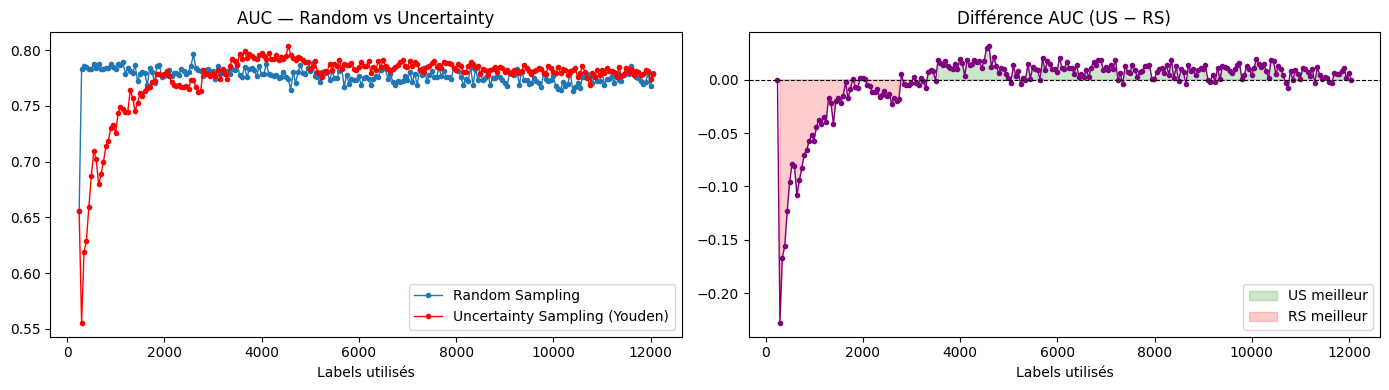

Moyenne diff AUC (US - RS) : -0.0023
US meilleur sur 164 itérations / 237 total
RS meilleur sur 71 itérations / 237 total

US meilleur à partir de l'itération :  1796


In [25]:
# ── Diagnostic : vérification de la stabilité du seuil de Youden ───────────
# Relance la boucle en mode dry-run pour tracer le seuil à chaque itération
# (nécessite de re-splitter depuis les variables originales)

import matplotlib.pyplot as plt

# Le seuil de Youden est-il stable ? Visualisation depuis results_df
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Comparaison AUC (métrique la plus robuste)
axes[0].plot(results_df['labels_used'], results_df['auc_random_sampling'],
             label='Random Sampling', marker='.', linewidth=1)
axes[0].plot(results_df['labels_used'], results_df['auc_uncertainty_sampling'],
             label='Uncertainty Sampling (Youden)', marker='.', linewidth=1, color='red')
axes[0].set_title('AUC — Random vs Uncertainty')
axes[0].set_xlabel('Labels utilisés')
axes[0].legend()

# Différence US - RS : positif = US meilleur
diff = results_df['auc_uncertainty_sampling'] - results_df['auc_random_sampling']
axes[1].plot(results_df['labels_used'], diff, color='purple', marker='.', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(results_df['labels_used'], diff, 0,
                     where=(diff > 0), alpha=0.2, color='green', label='US meilleur')
axes[1].fill_between(results_df['labels_used'], diff, 0,
                     where=(diff < 0), alpha=0.2, color='red', label='RS meilleur')
axes[1].set_title('Différence AUC (US − RS)')
axes[1].set_xlabel('Labels utilisés')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Moyenne diff AUC (US - RS) : {diff.mean():.4f}")
print(f"US meilleur sur {(diff > 0).sum()} itérations / {len(diff)} total")
print(f"RS meilleur sur {(diff < 0).sum()} itérations / {len(diff)} total")
print(f"\nUS meilleur à partir de l'itération : ",
      results_df.loc[diff > 0, 'labels_used'].min() if (diff > 0).any() else 'jamais')


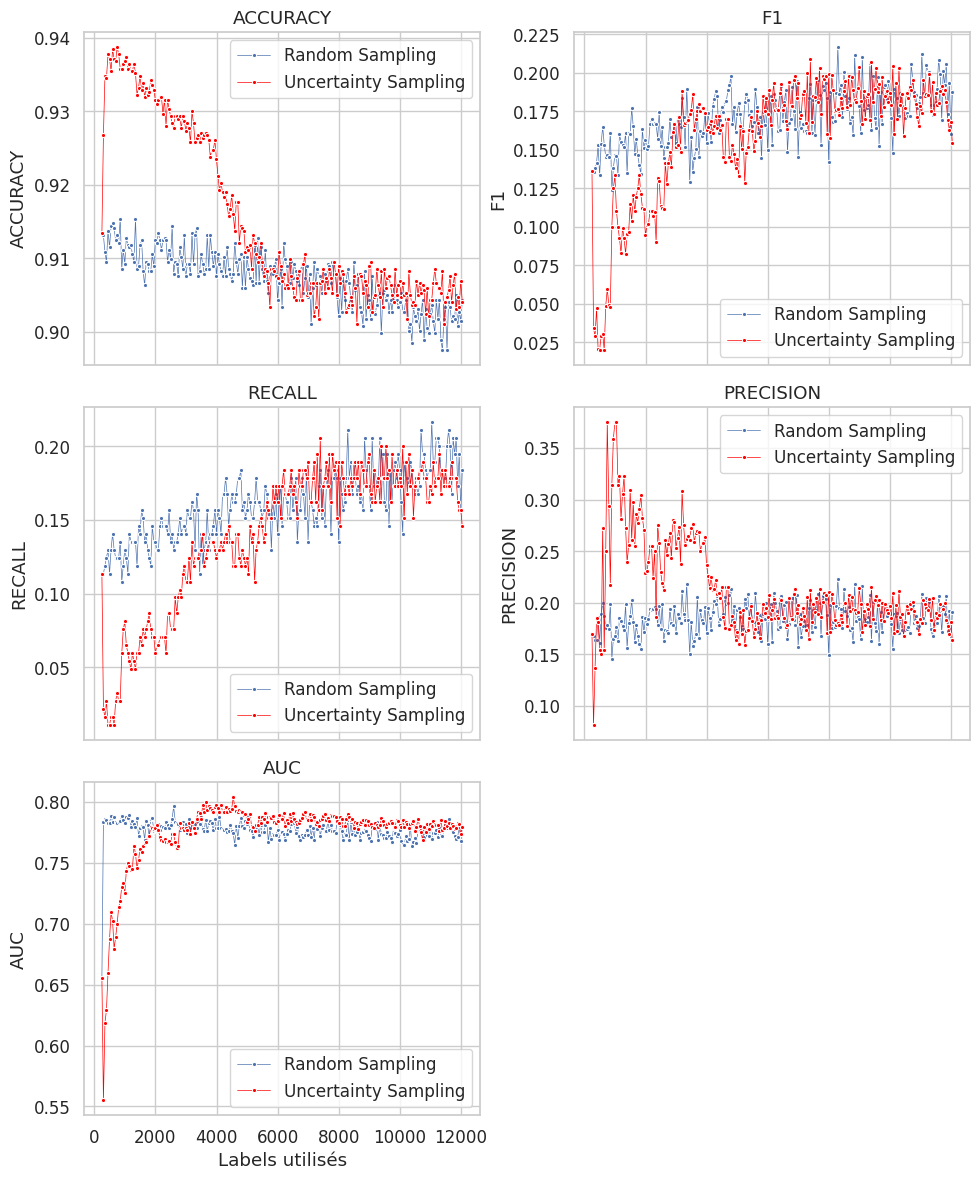

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

metrics = ["accuracy", "f1", "recall", "precision", "auc"]
n_metrics = len(metrics)

n_rows = 3
n_cols = math.ceil(n_metrics / n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=True
)

axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]

    sns.lineplot(
        x=results_df["labels_used"],
        y=results_df[f"{m}_random_sampling"],
        marker=".",
        linewidth=0.5,
        ax=ax,
        label="Random Sampling"
    )

    sns.lineplot(
        x=results_df["labels_used"],
        y=results_df[f"{m}_uncertainty_sampling"],
        marker=".",
        linewidth=0.5,
        ax=ax,
        label="Uncertainty Sampling",
        color = 'red'
    )

    ax.set_title(m.upper())
    ax.set_xlabel("Labels utilisés")
    ax.set_ylabel(m.upper())
    ax.legend()

# Supprimer les axes vides
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
